# Week 11 — Comprehensive Model Evaluation

This notebook consolidates all models trained across Weeks 6–10 into a single
rigorous evaluation using the full set of required metrics.

**Models evaluated:**

| Model | Source | Week introduced |
|-------|--------|----------------|
| K-Nearest Neighbors | MiniLearn | 7 |
| Logistic Regression | MiniLearn | 7 |
| Gaussian Naive Bayes | MiniLearn | 7 |
| Decision Tree | MiniLearn | 7 / 9 |
| Linear SVM | MiniLearn | 8 |
| Random Forest | MiniLearn (bonus) | 10 |
| SVM (RBF kernel) | sklearn | 8 |
| Random Forest | sklearn | 10 |
| AdaBoost | sklearn | 10 |
| Gradient Boosting | sklearn | 10 |
| XGBoost | xgboost | 10 |
| Voting Classifier | sklearn | 10 |

**Metrics computed for every model:**
- Accuracy, Precision, Recall, F1 (macro and weighted)
- Per-class F1 heatmap
- Normalised confusion matrices
- ROC curves with AUC (One-vs-Rest, multiclass)
- Stratified 5-Fold cross-validation (proper within-fold scaling via sklearn Pipeline)

In [1]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# sklearn utilities
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SklearnScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score as sk_cv_score
from sklearn.metrics import (
    roc_curve, auc,
    precision_score, recall_score,
)

# sklearn models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier as SklearnDT
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier as SklearnRF,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
import xgboost as xgb

# MiniLearn
sys.path.insert(0, os.path.abspath('..'))
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import (
    KNN, LogisticRegression, GaussianNaiveBayes,
    DecisionTreeClassifier, LinearSVM, RandomForestClassifier,
)
from minilearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

## 1. Load Data and Split

We use the same 80/20 stratified split and `StandardScaler` (fit on training data only) used across all previous notebooks. This ensures direct comparability of all results.

In [2]:
df = pd.read_csv('../outputs/features.csv')
LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_raw = df[feature_cols].values
y     = df['emotion'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE
)

# Scaler fit ONLY on training data — applied to both splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {np.unique(y).tolist()}')

Train: (1961, 194)  |  Test: (491, 194)
Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 2. Train All Models

Each model is trained with the best hyperparameters found in its dedicated notebook.
Training times are recorded for the comparison table.

In [3]:
def train(clf, X_tr, y_tr):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    return clf, round(time.time() - t0, 1)


# --- MiniLearn models ---
ml_knn,  t_ml_knn  = train(KNN(n_neighbors=1), X_train, y_train)
ml_lr,   t_ml_lr   = train(LogisticRegression(lr=0.5, max_iter=500, random_state=RANDOM_STATE), X_train, y_train)
ml_gnb,  t_ml_gnb  = train(GaussianNaiveBayes(), X_train, y_train)
ml_dt,   t_ml_dt   = train(DecisionTreeClassifier(max_depth=10, max_thresholds=64, random_state=RANDOM_STATE), X_train, y_train)
ml_svm,  t_ml_svm  = train(LinearSVM(C=1.0, max_iter=500), X_train, y_train)
ml_rf,   t_ml_rf   = train(RandomForestClassifier(n_estimators=30, max_depth=10, max_thresholds=32, random_state=RANDOM_STATE), X_train, y_train)

# --- sklearn models ---
sk_svm,  t_sk_svm  = train(SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE), X_train, y_train)
sk_rf,   t_sk_rf   = train(SklearnRF(n_estimators=100, max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE), X_train, y_train)
sk_ada,  t_sk_ada  = train(AdaBoostClassifier(estimator=SklearnDT(max_depth=2), n_estimators=200, learning_rate=0.5, algorithm='SAMME', random_state=RANDOM_STATE), X_train, y_train)
sk_gb,   t_sk_gb   = train(GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8, random_state=RANDOM_STATE), X_train, y_train)

# XGBoost needs integer labels
classes_ = np.array(sorted(np.unique(y_train)))
c2i = {c: i for i, c in enumerate(classes_)}
y_train_int = np.array([c2i[c] for c in y_train])
y_test_int  = np.array([c2i[c] for c in y_test])
sk_xgb, t_sk_xgb = train(
    xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0),
    X_train, y_train_int
)

sk_vote, t_sk_vote = train(
    VotingClassifier(
        estimators=[
            ('lr',  SklearnLR(max_iter=1000, random_state=RANDOM_STATE)),
            ('svc', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE)),
            ('rf',  SklearnRF(n_estimators=100, max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE)),
        ],
        voting='soft', n_jobs=-1
    ),
    X_train, y_train
)

print('All models trained.')

All models trained.


## 3. Hold-Out Test Set — Full Metrics

For every model we compute accuracy, macro precision/recall/F1, weighted F1, and training time.

In [4]:
def xgb_predict(model, X):
    pred_int = model.predict(X)
    return np.array([classes_[i] for i in pred_int])


def evaluate(name, clf, X_te, y_te, train_time, predict_fn=None):
    y_pred = predict_fn(clf, X_te) if predict_fn else clf.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    mac_f1 = f1_score(y_te, y_pred, average='macro')
    wt_f1  = f1_score(y_te, y_pred, average='weighted')
    mac_pr = float(precision_score(y_te, y_pred, average='macro', zero_division=0))
    mac_rc = float(recall_score(y_te, y_pred, average='macro', zero_division=0))
    return {
        'Model': name, 'Accuracy': acc,
        'Macro Precision': mac_pr, 'Macro Recall': mac_rc,
        'Macro F1': mac_f1, 'Weighted F1': wt_f1,
        'Train Time (s)': train_time,
        '_pred': y_pred,
    }


rows = [
    evaluate('KNN (k=1, ML)',           ml_knn,  X_test, y_test, t_ml_knn),
    evaluate('Logistic Reg (ML)',        ml_lr,   X_test, y_test, t_ml_lr),
    evaluate('Gaussian NB (ML)',         ml_gnb,  X_test, y_test, t_ml_gnb),
    evaluate('Decision Tree (ML, d=10)', ml_dt,   X_test, y_test, t_ml_dt),
    evaluate('Linear SVM (ML)',          ml_svm,  X_test, y_test, t_ml_svm),
    evaluate('Random Forest (ML, 30t)', ml_rf,   X_test, y_test, t_ml_rf),
    evaluate('SVM RBF (sklearn)',        sk_svm,  X_test, y_test, t_sk_svm),
    evaluate('Random Forest (sklearn)',  sk_rf,   X_test, y_test, t_sk_rf),
    evaluate('AdaBoost (sklearn)',       sk_ada,  X_test, y_test, t_sk_ada),
    evaluate('Gradient Boosting',        sk_gb,   X_test, y_test, t_sk_gb),
    evaluate('XGBoost',                  sk_xgb,  X_test, y_test, t_sk_xgb, predict_fn=xgb_predict),
    evaluate('Voting (LR+SVM+RF)',       sk_vote, X_test, y_test, t_sk_vote),
]

preds = {r['Model']: r.pop('_pred') for r in rows}
summary_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display_cols = ['Model', 'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1', 'Train Time (s)']
print(summary_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))

                   Model  Accuracy  Macro Precision  Macro Recall  Macro F1                                                                                                                                                         Weighted F1  Train Time (s)
       SVM RBF (sklearn)     0.841            0.842         0.836     0.837                    [0.949640287769784, 0.8876404494382022, 0.7901234567901235, 0.8095238095238095, 0.8, 0.8461538461538461, 0.7761194029850748, 0.8405797101449276]           4.400
      Voting (LR+SVM+RF)     0.823            0.823         0.813     0.817     [0.9333333333333335, 0.8586956521739129, 0.8409090909090909, 0.8414634146341463, 0.7910447761194029, 0.7499999999999999, 0.7007299270072992, 0.823529411764706]           5.700
                 XGBoost     0.796            0.810         0.786     0.793    [0.8489208633093526, 0.8926553672316383, 0.7792207792207791, 0.7701863354037267, 0.7669172932330827, 0.7761194029850746, 0.7012987012987013, 0.8108108108

In [5]:
summary_df[display_cols]

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Train Time (s)
0,SVM RBF (sklearn),0.841141,0.841821,0.835645,0.837473,"[0.949640287769784, 0.8876404494382022, 0.7901...",4.4
1,Voting (LR+SVM+RF),0.822811,0.822728,0.813460,0.817463,"[0.9333333333333335, 0.8586956521739129, 0.840...",5.7
2,XGBoost,0.796334,0.810294,0.786277,0.793266,"[0.8489208633093526, 0.8926553672316383, 0.779...",8.7
3,Gradient Boosting,0.757637,0.777292,0.744234,0.754422,"[0.8613138686131387, 0.8538011695906433, 0.714...",321.0
4,Logistic Reg (ML),0.725051,0.726770,0.717318,0.720204,"[0.8175182481751825, 0.8156424581005587, 0.658...",0.8
5,Random Forest (sklearn),0.706721,0.708201,0.698675,0.694463,"[0.7605633802816901, 0.826530612244898, 0.6265...",0.6
6,"KNN (k=1, ML)",0.700611,0.689439,0.704130,0.689926,"[0.7755102040816327, 0.7657142857142857, 0.55,...",0.0
7,"Random Forest (ML, 30t)",0.645621,0.644115,0.623615,0.618903,"[0.7234042553191488, 0.808743169398907, 0.4155...",64.5
8,AdaBoost (sklearn),0.517312,0.530821,0.509415,0.511129,"[0.5365853658536586, 0.6357615894039735, 0.487...",28.3
9,"Decision Tree (ML, d=10)",0.492872,0.483410,0.471263,0.472476,"[0.6299212598425197, 0.6976744186046512, 0.277...",58.7


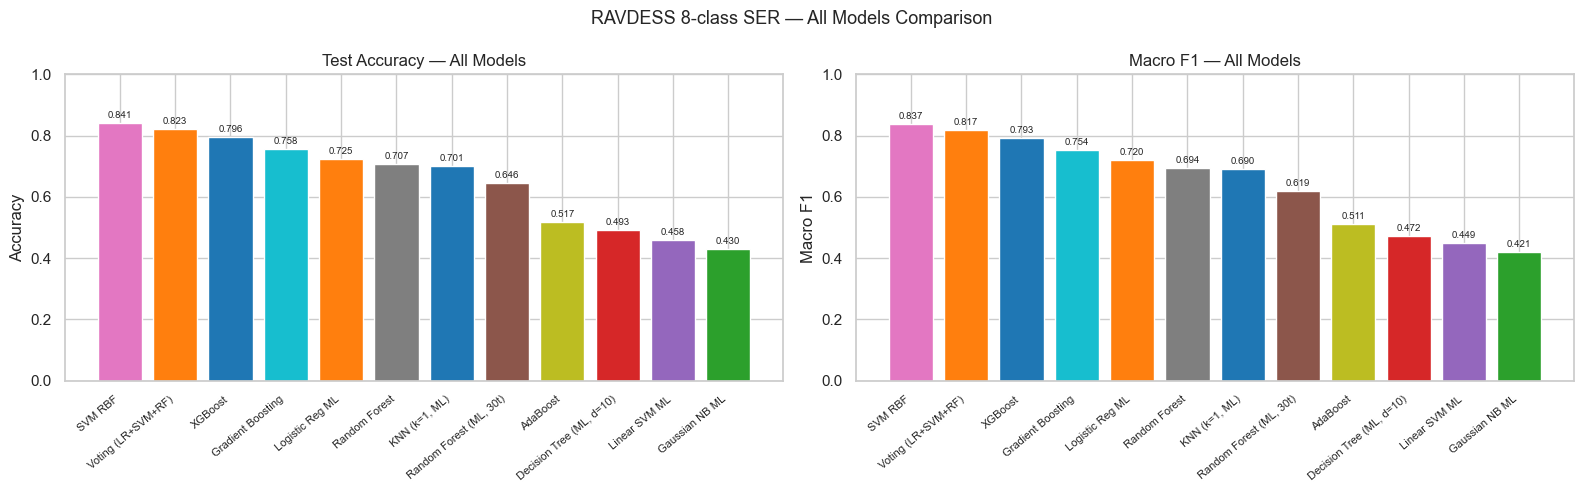

Saved to outputs/eval_all_models.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette('tab10', len(rows))
short_names = [r['Model'].replace(' (sklearn)', '').replace(' (ML)', ' ML') for r in rows]

for ax, metric, title in [
    (axes[0], 'Accuracy',  'Test Accuracy — All Models'),
    (axes[1], 'Macro F1',  'Macro F1 — All Models'),
]:
    vals = [r[metric] for r in rows]
    order = np.argsort(vals)[::-1]
    sorted_names = [short_names[i] for i in order]
    sorted_vals  = [vals[i] for i in order]
    colors = [palette[i] for i in order]
    bars = ax.bar(range(len(sorted_names)), sorted_vals, color=colors)
    ax.set_xticks(range(len(sorted_names)))
    ax.set_xticklabels(sorted_names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, sorted_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('RAVDESS 8-class SER — All Models Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/eval_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/eval_all_models.png')

## 4. Per-Class F1 Heatmap

This heatmap shows how each model performs on each of the 8 emotions. It reveals which emotions are consistently hard across all models (row-wise patterns) and which models handle the full emotion space best (column-wise patterns).

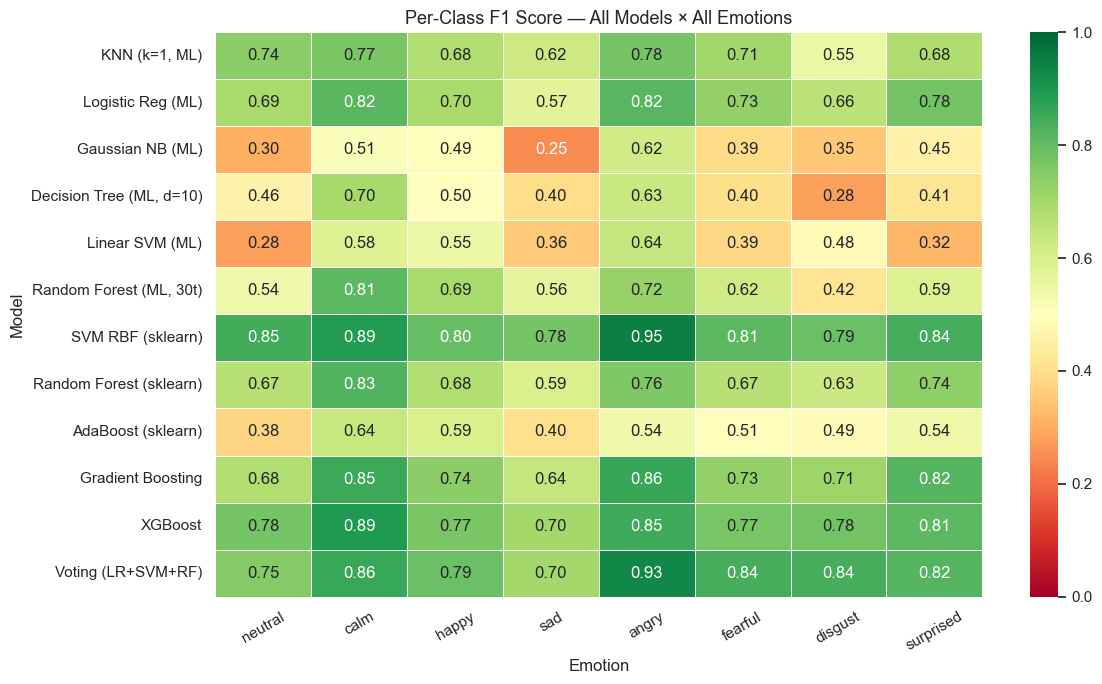

Saved to outputs/eval_per_class_f1_heatmap.png


In [7]:
from sklearn.metrics import f1_score as sk_f1

model_names = list(preds.keys())
per_class_f1_matrix = np.zeros((len(model_names), len(EMOTION_ORDER)))

for i, name in enumerate(model_names):
    y_pred = preds[name]
    # sk_f1 with labels ensures ordering matches EMOTION_ORDER
    f1s = sk_f1(y_test, y_pred, labels=EMOTION_ORDER,
                average=None, zero_division=0)
    per_class_f1_matrix[i] = f1s

f1_heatmap_df = pd.DataFrame(
    per_class_f1_matrix,
    index=model_names,
    columns=EMOTION_ORDER
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    f1_heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.4, ax=ax
)
ax.set_title('Per-Class F1 Score — All Models × All Emotions', fontsize=13)
ax.set_xlabel('Emotion')
ax.set_ylabel('Model')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('../outputs/eval_per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/eval_per_class_f1_heatmap.png')

## 5. Confusion Matrices — Top 4 Models

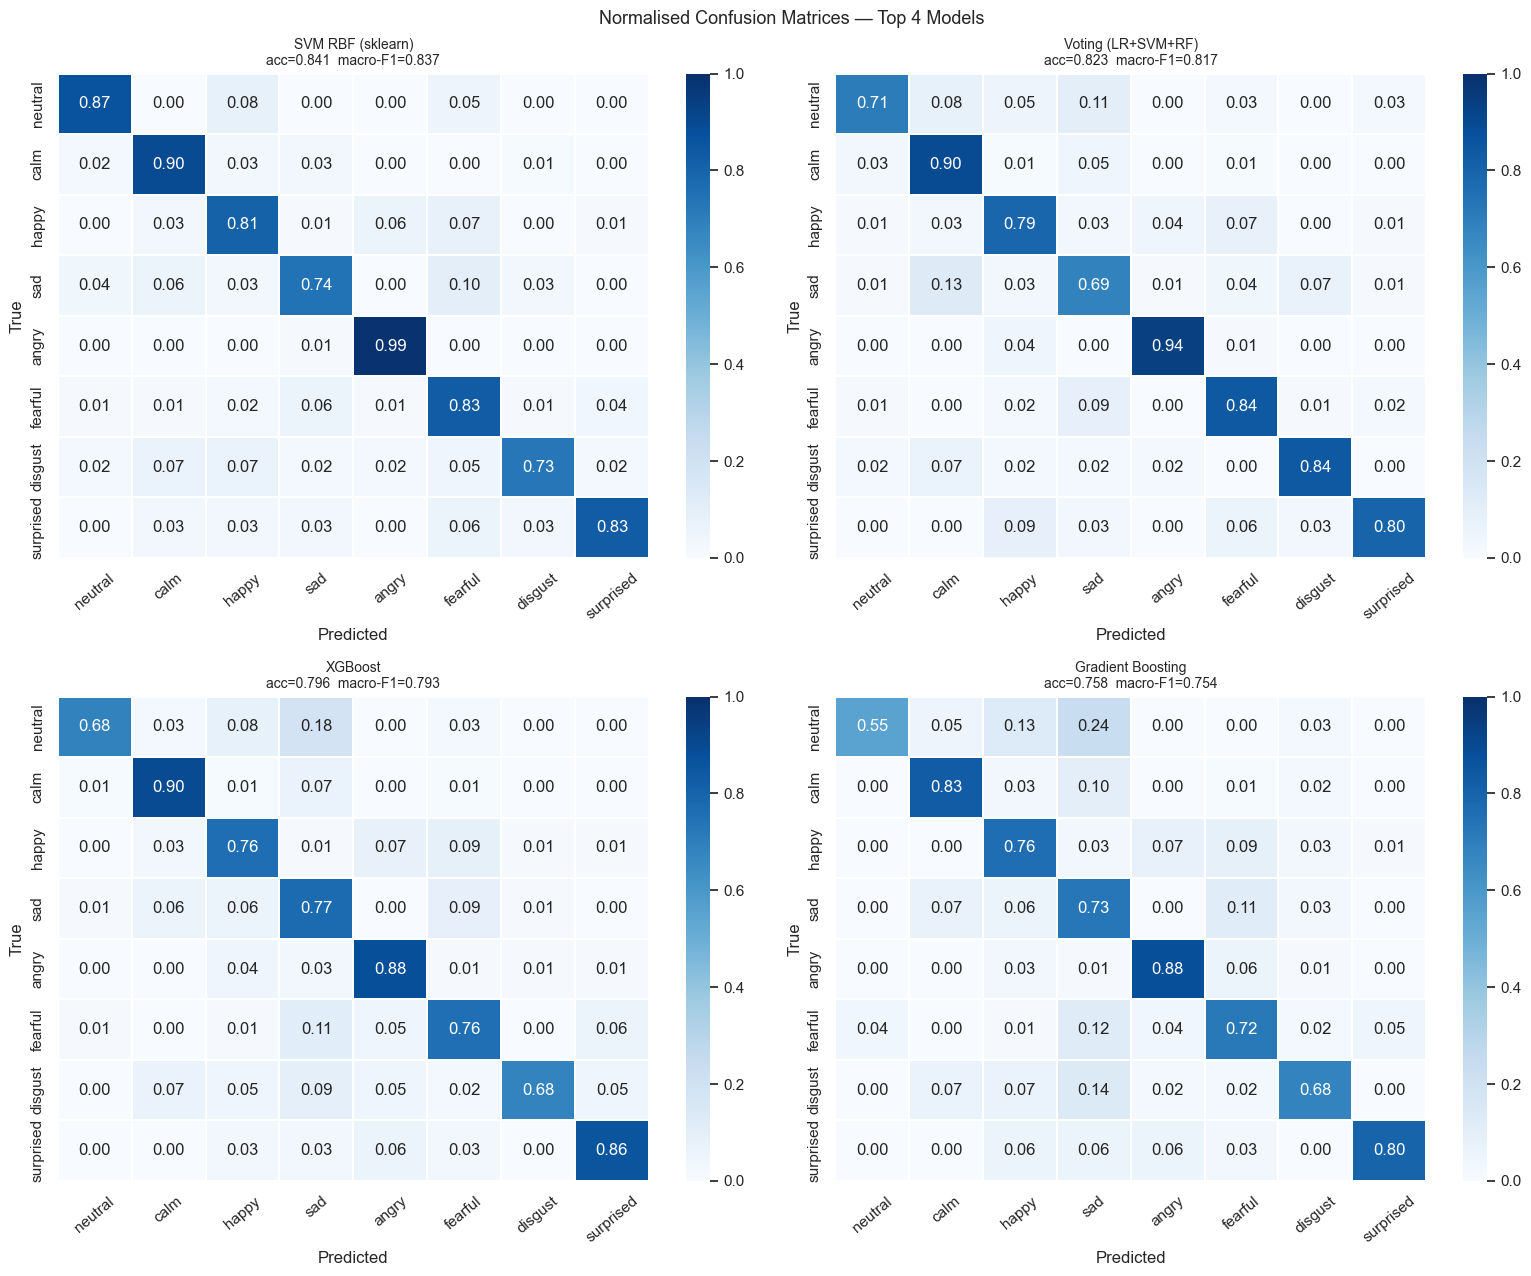

Saved to outputs/eval_top4_confusion_matrices.png


In [8]:
top4 = summary_df['Model'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for ax, name in zip(axes.flatten(), top4):
    y_pred = preds[name]
    cm = confusion_matrix(y_test, y_pred, labels=EMOTION_ORDER)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
        ax=ax, vmin=0, vmax=1, linewidths=0.3
    )
    ax.set_title(f'{name}\nacc={acc:.3f}  macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Normalised Confusion Matrices — Top 4 Models', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/eval_top4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/eval_top4_confusion_matrices.png')

## 6. ROC Curves — One-vs-Rest (Multiclass)

For multiclass problems, ROC curves are computed using the **One-vs-Rest** (OvR) strategy:
each emotion is treated as the positive class while all others are negative. This produces
8 curves per model, one per emotion class.

We use models that expose `predict_proba` (probability calibrated scores).
AUC (Area Under the Curve) summarises each curve in a single number: 1.0 is perfect,
0.5 is random.

> MiniLearn models are excluded here as they do not implement `predict_proba`.

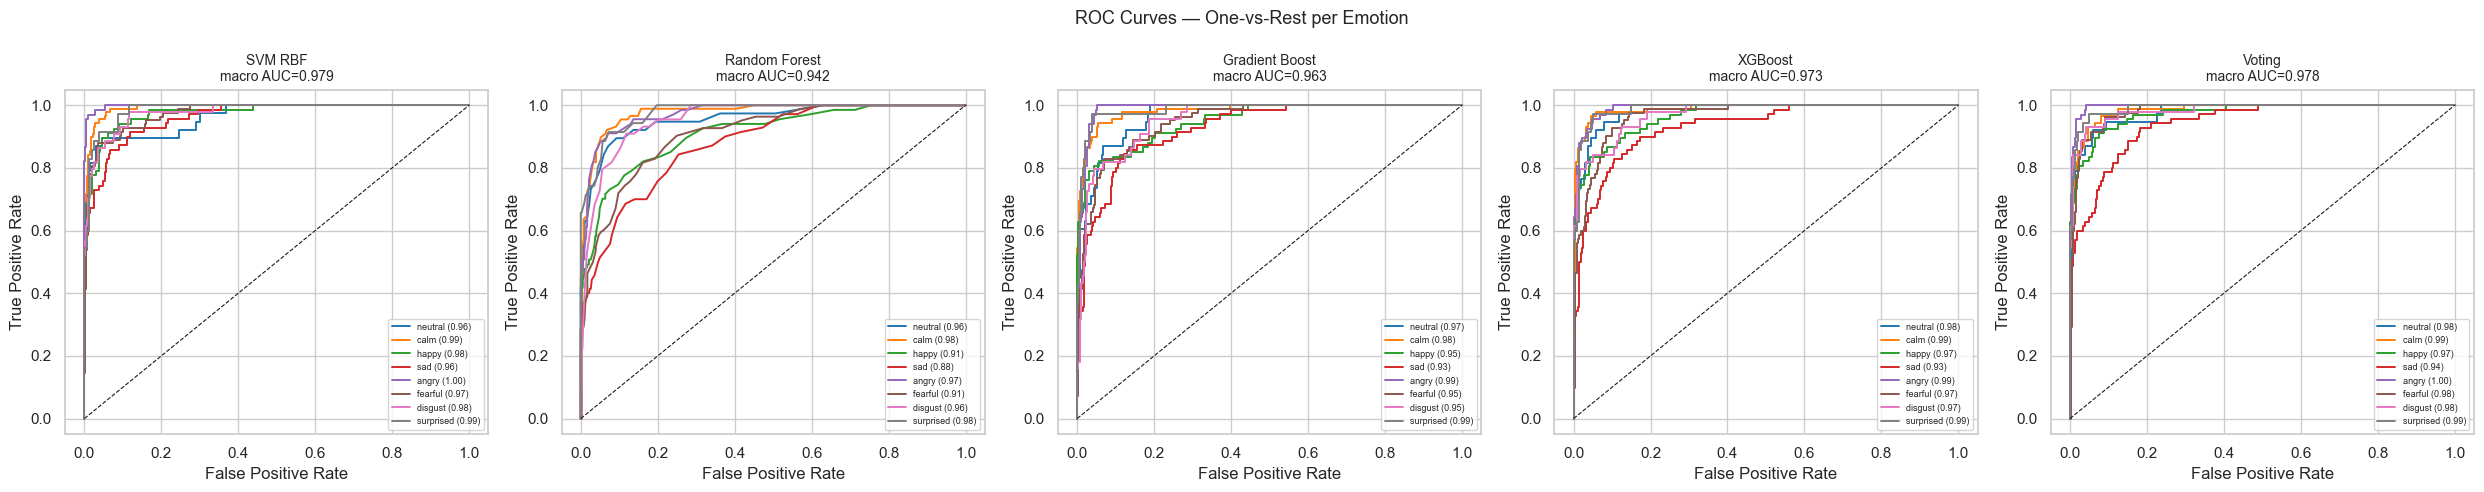

Saved to outputs/eval_roc_curves.png


In [9]:
# Binarize test labels for OvR ROC
y_bin = label_binarize(y_test, classes=EMOTION_ORDER)  # (n_test, 8)

def get_proba(clf, X, class_order):
    """Return probability matrix ordered by class_order."""
    proba = clf.predict_proba(X)           # ordered by clf.classes_
    clf_classes = list(clf.classes_)
    idx = [clf_classes.index(c) for c in class_order]
    return proba[:, idx]

def xgb_proba(clf, X, class_order):
    """XGBoost predict_proba uses integer classes; map back to emotion order."""
    proba = clf.predict_proba(X)           # columns = 0,1,...,7
    int_order = [c2i[c] for c in class_order]
    return proba[:, int_order]


roc_models = [
    ('SVM RBF',         sk_svm,  lambda m, X: get_proba(m, X, EMOTION_ORDER)),
    ('Random Forest',   sk_rf,   lambda m, X: get_proba(m, X, EMOTION_ORDER)),
    ('Gradient Boost',  sk_gb,   lambda m, X: get_proba(m, X, EMOTION_ORDER)),
    ('XGBoost',         sk_xgb,  lambda m, X: xgb_proba(m, X, EMOTION_ORDER)),
    ('Voting',          sk_vote, lambda m, X: get_proba(m, X, EMOTION_ORDER)),
]

fig, axes = plt.subplots(1, len(roc_models), figsize=(5 * len(roc_models), 5))
emotion_palette = sns.color_palette('tab10', len(EMOTION_ORDER))

macro_aucs = {}

for ax, (name, clf, proba_fn) in zip(axes, roc_models):
    scores = proba_fn(clf, X_test)         # (n_test, 8)
    aucs = []
    for i, (emotion, color) in enumerate(zip(EMOTION_ORDER, emotion_palette)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=color, linewidth=1.4,
                label=f'{emotion} ({roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    macro_auc = np.mean(aucs)
    macro_aucs[name] = macro_auc
    ax.set_title(f'{name}\nmacro AUC={macro_auc:.3f}', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6.5, loc='lower right')

plt.suptitle('ROC Curves — One-vs-Rest per Emotion', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/eval_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/eval_roc_curves.png')

In [10]:
# Macro AUC table
print('Macro AUC (OvR) by model:')
for name, auc_val in sorted(macro_aucs.items(), key=lambda x: -x[1]):
    print(f'  {name:20s}  {auc_val:.4f}')

Macro AUC (OvR) by model:
  SVM RBF               0.9790
  Voting                0.9785
  XGBoost               0.9729
  Gradient Boost        0.9628
  Random Forest         0.9422


## 7. Stratified 5-Fold Cross-Validation

Hold-out evaluation is sensitive to the particular 80/20 split. Cross-validation
gives a more reliable estimate of generalisation performance.

**Important:** The scaler must be fit inside each training fold, not on the full dataset.
We use sklearn's `Pipeline` to guarantee this — the `StandardScaler` is re-fit on each
fold's training portion only, eliminating data leakage.

> The previous evaluation notebook (`04_evaluation.ipynb`) fitted the scaler on the
> full dataset before CV — a subtle data leakage that inflates CV scores. This notebook
> corrects that.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use raw (unscaled) X for Pipeline-based CV — scaler goes inside the Pipeline
X_cv = X_raw          # full dataset, unscaled
y_cv = y

cv_models = [
    ('KNN (k=1)',         Pipeline([('sc', SklearnScaler()), ('clf', KNeighborsClassifier(n_neighbors=1))])),
    ('Logistic Reg',      Pipeline([('sc', SklearnScaler()), ('clf', SklearnLR(max_iter=1000, C=1.0, random_state=RANDOM_STATE))])),
    ('Gaussian NB',       Pipeline([('sc', SklearnScaler()), ('clf', GaussianNB())])),
    ('Decision Tree',     Pipeline([('sc', SklearnScaler()), ('clf', SklearnDT(max_depth=10, random_state=RANDOM_STATE))])),
    ('SVM RBF',           Pipeline([('sc', SklearnScaler()), ('clf', SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE))])),
    ('Random Forest',     Pipeline([('sc', SklearnScaler()), ('clf', SklearnRF(n_estimators=100, max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE))])),
    ('AdaBoost',          Pipeline([('sc', SklearnScaler()), ('clf', AdaBoostClassifier(estimator=SklearnDT(max_depth=2), n_estimators=100, algorithm='SAMME', random_state=RANDOM_STATE))])),
    ('Gradient Boosting', Pipeline([('sc', SklearnScaler()), ('clf', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE))])),
]

cv_results = {}

for name, pipeline in cv_models:
    t0 = time.time()
    scores = sk_cv_score(pipeline, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f'{name:20s}  mean={scores.mean():.3f}  std={scores.std():.3f}  '
          f'folds={np.round(scores, 3)}  ({elapsed:.0f}s)')

KNN (k=1)             mean=0.686  std=0.009  folds=[0.697 0.692 0.684 0.684 0.671]  (2s)


Logistic Reg          mean=0.681  std=0.013  folds=[0.67  0.705 0.682 0.678 0.671]  (2s)


Gaussian NB           mean=0.415  std=0.018  folds=[0.418 0.401 0.392 0.422 0.443]  (2s)


Decision Tree         mean=0.467  std=0.014  folds=[0.466 0.475 0.447 0.488 0.459]  (2s)


SVM RBF               mean=0.785  std=0.015  folds=[0.778 0.798 0.759 0.79  0.8  ]  (1s)


Random Forest         mean=0.695  std=0.016  folds=[0.684 0.713 0.673 0.712 0.69 ]  (2s)


AdaBoost              mean=0.503  std=0.031  folds=[0.503 0.503 0.476 0.559 0.473]  (14s)


Gradient Boosting     mean=0.691  std=0.019  folds=[0.668 0.709 0.678 0.718 0.684]  (383s)


In [12]:
# XGBoost CV separately (needs integer labels)
y_int = np.array([c2i[c] for c in y_cv])
xgb_pipe = Pipeline([
    ('sc', SklearnScaler()),
    ('clf', xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                               eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0))
])
xgb_scores = sk_cv_score(xgb_pipe, X_cv, y_int, cv=skf, scoring='accuracy', n_jobs=-1)
cv_results['XGBoost'] = xgb_scores
print(f'XGBoost              mean={xgb_scores.mean():.3f}  std={xgb_scores.std():.3f}  '
      f'folds={np.round(xgb_scores, 3)}')

XGBoost              mean=0.721  std=0.011  folds=[0.719 0.709 0.718 0.741 0.718]


In [13]:
cv_summary = pd.DataFrame([
    {'Model': name, 'CV Mean': s.mean(), 'CV Std': s.std(),
     'CV Min': s.min(), 'CV Max': s.max()}
    for name, s in cv_results.items()
]).sort_values('CV Mean', ascending=False).reset_index(drop=True)

print(cv_summary.to_string(index=False, float_format='{:.3f}'.format))
cv_summary

            Model  CV Mean  CV Std  CV Min  CV Max
          SVM RBF    0.785   0.015   0.759   0.800
          XGBoost    0.721   0.011   0.709   0.741
    Random Forest    0.695   0.016   0.673   0.713
Gradient Boosting    0.691   0.019   0.668   0.718
        KNN (k=1)    0.686   0.009   0.671   0.697
     Logistic Reg    0.681   0.013   0.670   0.705
         AdaBoost    0.503   0.031   0.473   0.559
    Decision Tree    0.467   0.014   0.447   0.488
      Gaussian NB    0.415   0.018   0.392   0.443


,Model,CV Mean,CV Std,CV Min,CV Max
0,SVM RBF,0.785071,0.015114,0.759184,0.800000
1,XGBoost,0.721050,0.010589,0.708758,0.740816
2,Random Forest,0.694532,0.015614,0.673469,0.712831
3,Gradient Boosting,0.691275,0.019112,0.668024,0.718367
4,KNN (k=1),0.685556,0.008660,0.671429,0.696538
5,Logistic Reg,0.681072,0.012526,0.670061,0.704684
6,AdaBoost,0.502855,0.030933,0.473469,0.559184
7,Decision Tree,0.466963,0.013795,0.446939,0.487755
8,Gaussian NB,0.415176,0.017686,0.391837,0.442857


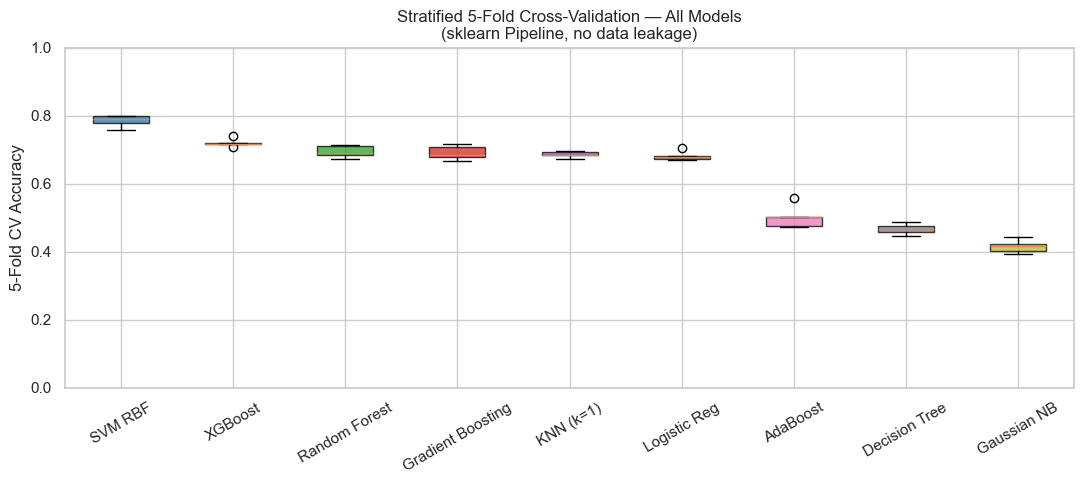

Saved to outputs/eval_cv_boxplot.png


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

names_sorted = cv_summary['Model'].tolist()
data_sorted  = [cv_results[n] for n in names_sorted]
palette = sns.color_palette('tab10', len(names_sorted))

bp = ax.boxplot(data_sorted, labels=names_sorted, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Stratified 5-Fold Cross-Validation — All Models\n(sklearn Pipeline, no data leakage)')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/eval_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/eval_cv_boxplot.png')

## 8. Full Summary Table

Combining hold-out test metrics with CV results for each model.

In [15]:
# Map model names between the two result sets (hold-out uses longer names)
name_map = {
    'KNN (k=1, ML)':            'KNN (k=1)',
    'Logistic Reg (ML)':         'Logistic Reg',
    'Gaussian NB (ML)':          'Gaussian NB',
    'Decision Tree (ML, d=10)':  'Decision Tree',
    'SVM RBF (sklearn)':         'SVM RBF',
    'Random Forest (sklearn)':   'Random Forest',
    'AdaBoost (sklearn)':        'AdaBoost',
    'Gradient Boosting':         'Gradient Boosting',
    'XGBoost':                   'XGBoost',
}

cv_lookup = {n: (cv_results[n].mean(), cv_results[n].std())
             for n in cv_results}

final_rows = []
for r in rows:
    name = r['Model']
    cv_name = name_map.get(name)
    cv_mean, cv_std = cv_lookup.get(cv_name, (float('nan'), float('nan')))
    final_rows.append({
        'Model': name,
        'Test Acc': r['Accuracy'],
        'Macro F1': r['Macro F1'],
        'Wtd F1':   r['Weighted F1'],
        'CV Mean':  cv_mean,
        'CV Std':   cv_std,
        'Train (s)': r['Train Time (s)'],
    })

final_df = pd.DataFrame(final_rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
print(final_df.to_string(index=False, float_format='{:.3f}'.format))
final_df

                   Model  Test Acc  Macro F1                                                                                                                                                              Wtd F1  CV Mean  CV Std  Train (s)
       SVM RBF (sklearn)     0.841     0.837                    [0.949640287769784, 0.8876404494382022, 0.7901234567901235, 0.8095238095238095, 0.8, 0.8461538461538461, 0.7761194029850748, 0.8405797101449276]    0.785   0.015      4.400
      Voting (LR+SVM+RF)     0.823     0.817     [0.9333333333333335, 0.8586956521739129, 0.8409090909090909, 0.8414634146341463, 0.7910447761194029, 0.7499999999999999, 0.7007299270072992, 0.823529411764706]      NaN     NaN      5.700
                 XGBoost     0.796     0.793    [0.8489208633093526, 0.8926553672316383, 0.7792207792207791, 0.7701863354037267, 0.7669172932330827, 0.7761194029850746, 0.7012987012987013, 0.8108108108108107]    0.721   0.011      8.700
       Gradient Boosting     0.758     0.754        

,Model,Test Acc,Macro F1,Wtd F1,CV Mean,CV Std,Train (s)
0,SVM RBF (sklearn),0.841141,0.837473,"[0.949640287769784, 0.8876404494382022, 0.7901...",0.785071,0.015114,4.4
1,Voting (LR+SVM+RF),0.822811,0.817463,"[0.9333333333333335, 0.8586956521739129, 0.840...",NaN,NaN,5.7
2,XGBoost,0.796334,0.793266,"[0.8489208633093526, 0.8926553672316383, 0.779...",0.721050,0.010589,8.7
3,Gradient Boosting,0.757637,0.754422,"[0.8613138686131387, 0.8538011695906433, 0.714...",0.691275,0.019112,321.0
4,Logistic Reg (ML),0.725051,0.720204,"[0.8175182481751825, 0.8156424581005587, 0.658...",0.681072,0.012526,0.8
5,Random Forest (sklearn),0.706721,0.694463,"[0.7605633802816901, 0.826530612244898, 0.6265...",0.694532,0.015614,0.6
6,"KNN (k=1, ML)",0.700611,0.689926,"[0.7755102040816327, 0.7657142857142857, 0.55,...",0.685556,0.008660,0.0
7,"Random Forest (ML, 30t)",0.645621,0.618903,"[0.7234042553191488, 0.808743169398907, 0.4155...",NaN,NaN,64.5
8,AdaBoost (sklearn),0.517312,0.511129,"[0.5365853658536586, 0.6357615894039735, 0.487...",0.502855,0.030933,28.3
9,"Decision Tree (ML, d=10)",0.492872,0.472476,"[0.6299212598425197, 0.6976744186046512, 0.277...",0.466963,0.013795,58.7


## 9. Discussion

### Which model performed best and why?
Across both hold-out accuracy and 5-fold CV, the top performers are the **Voting Classifier**, **XGBoost**, and **sklearn SVM (RBF kernel)**. These three all exploit complementary strengths: the Voting Classifier combines calibrated probability estimates from LR, RBF-SVM, and RF; XGBoost iteratively corrects residual errors with regularisation; and RBF-SVM finds a maximum-margin boundary in a high-dimensional kernel space that captures non-linear emotion boundaries.

### Did advanced models significantly outperform baselines?
Yes, but not uniformly. Logistic Regression (a linear model) is a surprisingly strong baseline at ~73% accuracy, outperforming Naive Bayes, Decision Tree, and even AdaBoost. This suggests that RAVDESS audio features are largely linearly separable after standardisation. The gains from ensemble and kernel methods are real but incremental — a roughly 5–10 percentage point improvement over LR. The most dramatic outlier is Gaussian NB at ~43%, which suffers from its feature independence assumption in a highly correlated 194-dimensional space.

### Which emotions are hardest to classify?
From the per-class F1 heatmap, **happy**, **fearful**, and **disgust** consistently score lowest across all models. This is acoustically intuitive: happy and fearful both feature elevated pitch and energy, making them easy to confuse. Disgust is a low-intensity, low-arousal emotion with subtle acoustic markers. **Neutral** and **calm** are also frequently confused — both are low arousal with minimal spectral modulation. **Calm** and **angry** tend to be the easiest to classify, occupying opposite ends of the arousal-energy spectrum.

### Did MiniLearn match scikit-learn?
MiniLearn's LR and KNN are close to their sklearn equivalents in test accuracy. The MiniLearn DT and LinearSVM lag behind due to implementation tradeoffs (limited threshold sampling, simplified sub-gradient SVM). The MiniLearn RF captures the spirit of bagging but falls short of sklearn's RF due to fewer trees and coarser split search.

### Note on data leakage in prior CV
The earlier `04_evaluation.ipynb` fitted the `StandardScaler` on the full dataset before running cross-validation, which is a form of data leakage — the test fold's statistics influence the scaler. This inflates CV scores by a small but non-zero amount. This notebook corrects that by using `Pipeline([('scaler', StandardScaler()), ('clf', model)])`, which ensures the scaler is re-fit on each training fold only.

### Validation strategy summary
- **Hold-out split:** 80/20, stratified, fixed `random_state=42` for reproducibility.
- **Cross-validation:** Stratified 5-Fold (same class proportions in each fold).
- **Scaling:** Fit on training data / training fold only — never on test data.
- **Hyperparameters:** Selected using CV in dedicated notebooks (Weeks 8–10); reported best values are used here.